# Analiza hantavirusa korišćenjem nukleotidnih k-mera

**Modeli za određivanje vrste hantavirusa (klasifikacija)**

## Vrste hantavirusa
| Virus | Naziv vrste | TAXID |
|---|---|---|
| Hantaan virus | *Orthohantavirus hantanense* | 3052480 |
| Dobrava-Belgrade virus | *Orthohantavirus dobravaense* | 3052477 |
| Puumala virus | *Orthohantavirus puumalaense* | 3052493 |
| Sin Nombre virus | *Orthohantavirus sinnombreense* | 3052499 |

## Skupovi podataka
- **Skup 1** (`data/raw/all/`) - sve sekvence, bez ambiguous karaktera
- **Skup 2** (`data/raw/complete/`) - samo kompletne sekvence, bez ambiguous karaktera

## Biološka osnova

Hantavirusi su RNA virusi koji inficiraju glodare kao prirodne domaćine, a na ljude se prenose udisanjem aerosola zaraženih ekskreta (urina, fecesa, pljuvačke). Ne prenose se sa čoveka na čoveka. Prema geografskom poreklu i kliničkoj slici dele se na dve grupe:

### Virusi Starog sveta (Evroazija) - uzrokuju HFRS

**HFRS** (*Hemorrhagic Fever with Renal Syndrome*) je hemoragijska groznica sa bubrežnim sindromom. Karakterišu je visoka temperatura, krvarenja i zatajenje bubrega, dok smrtnost zavisi od virusa (1-15%).

| Virus | Region | Domaćin | Smrtnost |
|-------|--------|---------|---------|
| **Hantaan** | Koreja, Kina, Rusija | *Apodemus agrarius* (azijski prugasti poljski miš) | 5-15% |
| **Dobrava-Belgrade** | Balkan, centralna Evropa | *Apodemus flavicollis* (evropski žutogrli miš) | 1-12% |
| **Puumala** | Skandinavija, severna i centralna Evropa | *Myodes glareolus* (šumska voluharica / bank vole) | <1% |

### Virusi Novog sveta (Amerike) - uzrokuju HPS

**HPS** (*Hantavirus Pulmonary Syndrome*) je hantavirusni plućni sindrom. Za razliku od HFRS, ovaj oblik napada pluća, a ne bubrege, i ima dramatično višu smrtnost.

| Virus | Region | Domaćin | Smrtnost |
|-------|--------|---------|---------|
| **Sin Nombre** | Severna Amerika (jugozapad SAD) | *Peromyscus maniculatus* (jelenji miš / deer mouse) | ≈35% |


Hantavirusi su **koevoluirali sa svojim domaćinima** milionima godina. Kada su se linije glodara Starog i Novog sveta evolutivno razdvojile, zajedno s njima su se razdvojile i virusne linije. Posledica toga je da su virusi unutar iste grupe genomski sličniji jedni drugima, nego virusima druge grupe. Ova evolutivna udaljenost vidljiva je i u k-mer profilima, što je jedan od razloga zašto k-mer analiza može da razlikuje vrste.

---
## 1. Uvoz biblioteka i konfiguracija

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from Bio import SeqIO
from itertools import product

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
import joblib

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

In [2]:
BASE_DIR = os.path.abspath('.')
RAW_ALL = os.path.join(BASE_DIR, 'data', 'raw', 'all')
RAW_COMP = os.path.join(BASE_DIR, 'data', 'raw', 'complete')
PROC_DIR = os.path.join(BASE_DIR, 'data', 'processed')
FIG_DIR = os.path.join(BASE_DIR, 'results', 'figures')
TAB_DIR = os.path.join(BASE_DIR, 'results', 'tables')
MOD_DIR = os.path.join(BASE_DIR, 'models')

for d in [RAW_ALL, RAW_COMP, PROC_DIR, FIG_DIR, TAB_DIR, MOD_DIR]:
    os.makedirs(d, exist_ok=True)

VIRUSES = {
    'Hantaan': 3052480,
    'Dobrava_Belgrade': 3052477,
    'Puumala': 3052493,
    'Sin_Nombre': 3052499,
}

SPECIES_LABELS = {
    'Hantaan': 'Hantaan',
    'Dobrava_Belgrade': 'Dobrava-Belgrade',
    'Puumala': 'Puumala',
    'Sin_Nombre': 'Sin Nombre',
}

sns.set_theme(style='whitegrid', palette='tab10')
PALETTE = sns.color_palette('tab10', 4)
COLOR_MAP = {sp: PALETTE[i] for i, sp in enumerate(VIRUSES)}

---
## 2. Provera prisutnosti fajlova

Očekivana struktura foldera:
```
data/raw/
  all/
    Hantaan.fasta
    Dobrava_Belgrade.fasta
    Puumala.fasta
    Sin_Nombre.fasta
  complete/
    Hantaan.fasta
    Dobrava_Belgrade.fasta
    Puumala.fasta
    Sin_Nombre.fasta
```

In [3]:
def find_fasta(folder, species_key):
    """Pronalazi fasta fajl u folderu."""
    target = species_key.lower()
    for fname in os.listdir(folder):
        if fname.lower().replace('.fasta', '') == target and fname.lower().endswith('.fasta'):
            return os.path.join(folder, fname)
    return None

def check_files(folder, label):
    print(f"\n--- {label} ---")
    ok = True
    for name in VIRUSES:
        path = find_fasta(folder, name)
        if path:
            n = sum(1 for _ in SeqIO.parse(path, 'fasta'))
            print(f"  OK  {os.path.basename(path)}  ({n} sekvenci)")
        else:
            print(f"  NEDOSTAJE  fajl za '{name}' u {folder}")
            ok = False
    return ok

ok1 = check_files(RAW_ALL, 'Skup 1 - sve sekvence')
ok2 = check_files(RAW_COMP, 'Skup 2 - samo kompletne')

if ok1 and ok2:
    print("\nSvi fajlovi prisutni.")
else:
    print("\nNedostaju fajlovi.")


--- Skup 1 - sve sekvence ---
  OK  hantaan.fasta  (2342 sekvenci)
  OK  dobrava_belgrade.fasta  (790 sekvenci)
  OK  puumala.fasta  (3697 sekvenci)
  OK  sin_nombre.fasta  (397 sekvenci)

--- Skup 2 - samo kompletne ---
  OK  hantaan.fasta  (250 sekvenci)
  OK  dobrava_belgrade.fasta  (40 sekvenci)
  OK  puumala.fasta  (127 sekvenci)
  OK  sin_nombre.fasta  (18 sekvenci)

Svi fajlovi prisutni.


## 3. Učitavanje i filtriranje sekvenci

Svaka FASTA sekvenca u bazi može da sadrži tzv. **ambiguous karaktere**, slova koja ne predstavljaju konkretnu bazu, već neizvesnost pri sekvenciranju:

| Karakter | Značenje |
|----------|----------|
| R | A ili G |
| Y | C ili T |
| W | A ili T |
| S | C ili G |
| M | A ili C |
| K | G ili T |
| H | A, C ili T |
| B | C, G ili T |
| V | A, C ili G |
| D | A, G ili T |
| N | bilo koja baza |

### Zašto ih filtriramo?

K-mer analiza podrazumeva da znamo tačnu sekvencu baza - računamo koliko puta se svaka kombinacija (npr. `ACGT`) pojavljuje u genomu. Ako sekvenca sadrži `N` ili `R`, ta pozicija je nepoznata i ne možemo je jednoznačno svrstati ni u jedan k-mer. Takve sekvence bi unele šum u frekvencije i narušile pouzdanost modela.

Iz tog razloga zadržavamo **samo sekvence sastavljene isključivo od A, C, G i T**.

Pri preuzimanju sekvenci sa NCBI već je primenjen filter `Maximum number of ambiguous characters = 0`. Međutim, filtriranje se ovde ponavlja jer NCBI filter može biti manje striktan, može koristiti drugačiji prag (isključuje sekvence sa previše `N`-ova, ali ne i one sa po jednim `R`, `Y` i sl.), ili može potpuno zanemariti ređe IUPAC kodove. Ovaj filter je stroži, jer odbacuje sekvencu ako se **ijedan** ambiguous karakter pojavi na **bilo kojoj** poziciji.

In [4]:
AMBIGUOUS = set('RYWSMKHBVDN')

def load_fasta_folder(folder):
    records = []
    for name in VIRUSES:
        path = find_fasta(folder, name)
        if path is None:
            print(f"  PRESKOČENO: nema fajla za {name}")
            continue
        total, kept = 0, 0
        for rec in SeqIO.parse(path, 'fasta'):
            total += 1
            seq = str(rec.seq).upper()
            if not any(c in AMBIGUOUS for c in seq):
                gc = (seq.count('G') + seq.count('C')) / len(seq) * 100 if seq else 0
                records.append({
                    'id': rec.id,
                    'desc': rec.description,
                    'species': name,
                    'label': SPECIES_LABELS[name],
                    'seq': seq,
                    'length': len(seq),
                    'gc': round(gc, 2),
                })
                kept += 1
        print(f"  {name}: {kept}/{total} sekvenci prošlo filter")
    return pd.DataFrame(records)

print("Skup 1 - sve sekvence:")
df_all = load_fasta_folder(RAW_ALL)

print("\nSkup 2 - samo kompletne:")
df_complete = load_fasta_folder(RAW_COMP)

print(f"\nUkupno - Skup 1: {len(df_all)} sekvenci")
print(f"Ukupno - Skup 2: {len(df_complete)} sekvenci")

Skup 1 - sve sekvence:
  Hantaan: 2323/2342 sekvenci prošlo filter
  Dobrava_Belgrade: 780/790 sekvenci prošlo filter
  Puumala: 3641/3697 sekvenci prošlo filter
  Sin_Nombre: 389/397 sekvenci prošlo filter

Skup 2 - samo kompletne:
  Hantaan: 249/250 sekvenci prošlo filter
  Dobrava_Belgrade: 38/40 sekvenci prošlo filter
  Puumala: 123/127 sekvenci prošlo filter
  Sin_Nombre: 18/18 sekvenci prošlo filter

Ukupno - Skup 1: 7133 sekvenci
Ukupno - Skup 2: 428 sekvenci


---
## 4. Pregled podataka

Prikazujemo koliko sekvenci imamo po vrsti virusa u svakom skupu podataka. Ovo je važan prvi korak jer **neuravnotežen skup podataka** (*class imbalance*) može negativno uticati na treniranje modela, algoritam postaje "pristrasan" prema brojnijim klasama i može loše da klasifikuje retke klase.

### 4.1 Prikaz primera sekvenci

Nukleotidne sekvence u FASTA formatu sastoje se od četiri baze:
- **A** - Adenin
- **C** - Citozin  
- **G** - Guanin
- **T** - Timin

Svaka sekvenca ima zaglavlje (ID i opis) i samu nukleotidnu sekvencu. Prikazujemo po jednu sekvencu iz svakog virusa iz oba skupa.

In [5]:
def prikaz_sekvenci(df, naziv_skupa, n_prikaz=60):
    print(f"{'='*70}")
    print(f"  {naziv_skupa}")
    print(f"{'='*70}")
    for name in VIRUSES:
        grp = df[df['species'] == name]
        if grp.empty:
            continue
        row = grp.iloc[0]
        seq_preview = row['seq'][:n_prikaz] + ('...' if len(row['seq']) > n_prikaz else '')
        print(f"\nVrsta:    {SPECIES_LABELS[name]}")
        print(f"ID:       {row['id']}")
        print(f"Opis:     {row['desc'][:80]}")
        print(f"Dužina:   {row['length']:,} bp")
        print(f"GC:       {row['gc']} %")
        print(f"Sekvenca: {seq_preview}")
        print(f"          (prvih {n_prikaz} od {row['length']} baza)")

prikaz_sekvenci(df_all, "SKUP 1 - sve sekvence")
prikaz_sekvenci(df_complete, "SKUP 2 - samo kompletne sekvence")

  SKUP 1 - sve sekvence

Vrsta:    Hantaan
ID:       NC_005218.1
Opis:     NC_005218.1 |Hantaan virus, complete genome
Dužina:   1,696 bp
GC:       42.92 %
Sekvenca: TAGTAGTAGACTCCCTAAAGAGCTACTAGAACAACGATGGCAACTATGGAGGAATTACAG...
          (prvih 60 od 1696 baza)

Vrsta:    Dobrava-Belgrade
ID:       NC_005233.1
Opis:     NC_005233.1 |Dobrava virus complete S segment gene for nucleocapsid protein, str
Dužina:   1,673 bp
GC:       43.93 %
Sekvenca: TAGTAGTAGGCTCCCTAAAAAGCACTACACTAAAGATGGCAACATTAGAGGAACTCCAAA...
          (prvih 60 od 1673 baza)

Vrsta:    Puumala
ID:       NC_077666.1
Opis:     NC_077666.1 |Puumala virus CG1820 virus M genome segment, complete cds
Dužina:   3,682 bp
GC:       39.03 %
Sekvenca: TAGTAGTAGACTCCGCAAGAAGAAGCAAACACAGATCAATATGGGAGAACTTAGTCCAGT...
          (prvih 60 od 3682 baza)

Vrsta:    Sin Nombre
ID:       NC_077669.1
Opis:     NC_077669.1 |Sin Nombre virus (NM R11) RNA S segment encoding nucleocapsid prote
Dužina:   2,060 bp
GC:       38.59 %
Sekvenca: T

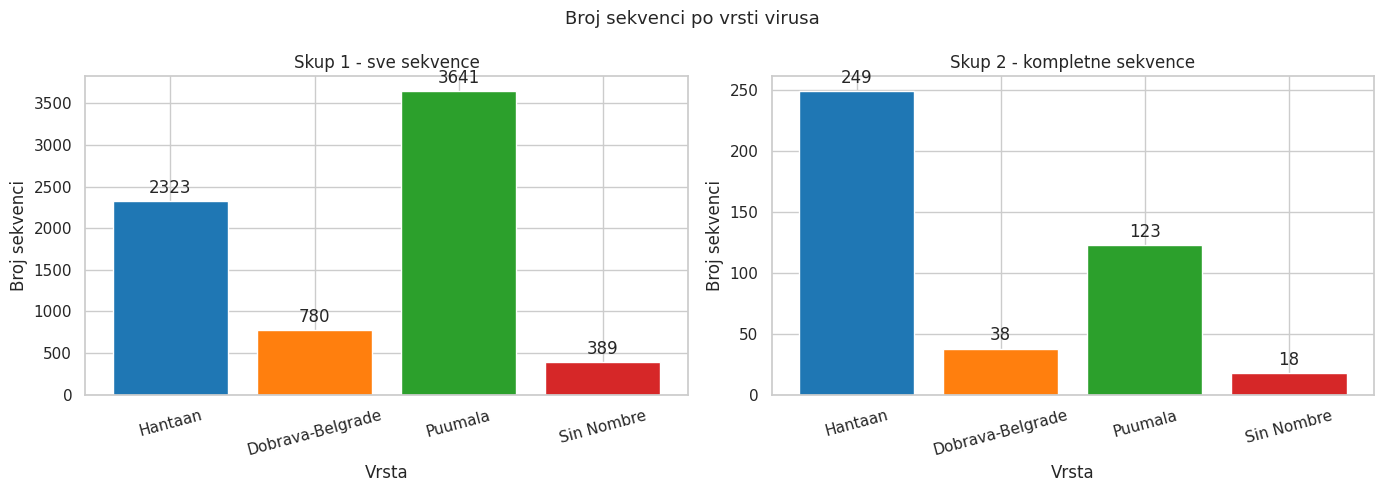


Skup 1:
                  n_sekvenci
label                       
Dobrava-Belgrade         780
Hantaan                 2323
Puumala                 3641
Sin Nombre               389

Skup 2:
                  n_sekvenci
label                       
Dobrava-Belgrade          38
Hantaan                  249
Puumala                  123
Sin Nombre                18


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df, title) in zip(axes, [(df_all, 'Skup 1 - sve sekvence'),(df_complete, 'Skup 2 - kompletne sekvence')]):
    counts = df.groupby('label').size().reindex([SPECIES_LABELS[k] for k in VIRUSES])
    bars = ax.bar(counts.index, counts.values, color=PALETTE)
    ax.bar_label(bars, padding=3)
    ax.set_title(title)
    ax.set_xlabel('Vrsta')
    ax.set_ylabel('Broj sekvenci')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Broj sekvenci po vrsti virusa', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_counts.png'), dpi=150)
plt.show()

print("\nSkup 1:")
print(df_all.groupby('label').size().rename('n_sekvenci').to_frame())
print("\nSkup 2:")
print(df_complete.groupby('label').size().rename('n_sekvenci').to_frame())

**Zapažanja:**
- U oba skupa, **Puumala** i **Hantaan** dominiraju po broju sekvenci, dok **Sin Nombre** ima najmanji broj (svega 18 kompletnih sekvenci)
- Ovakva neravnoteža je tipična za javne baze podataka, jer virusi koji su istorijski više istraživani (Hantaan, Puumala) imaju više deponovanih sekvenci
- U skupu kompletnih sekvenci neuravnoteženost je još izraženija, što treba uzeti u obzir pri interpretaciji rezultata klasifikacije (loša tačnost na Sin Nombre klasi može biti posledica malog uzorka, a ne lošeg modela)

### 4.2 Distribucija dužina sekvenci

Histogram prikazuje raspored sekvenci po dužini (izraženo u baznim parovima, ***bp***). Hantavirusni genom se sastoji od **tri segmenta**, od kojih svaki nosi uputstvo za drugačiji protein:

| Segment | Naziv | Tipična dužina | Šta kodira |
|---------|-------|----------------|------------|
| S | Small | ≈1.700 - 1.900 bp | Nukleokapsidni protein - obavija i štiti RNK unutar virusne čestice |
| M | Medium | ≈3.500 - 3.700 bp | Glikoproteini - omogućavaju virusu da prepozna i uđe u ćeliju domaćina |
| L | Large | ≈6.400 - 6.600 bp | RNA polimeraza - enzim koji umnožava virusni genom unutar zaražene ćelije |

Zbog toga očekujemo **trimodalnu distribuciju**, tj. tri odvojena "vrha" u histogramu koji odgovaraju svakom segmentu.

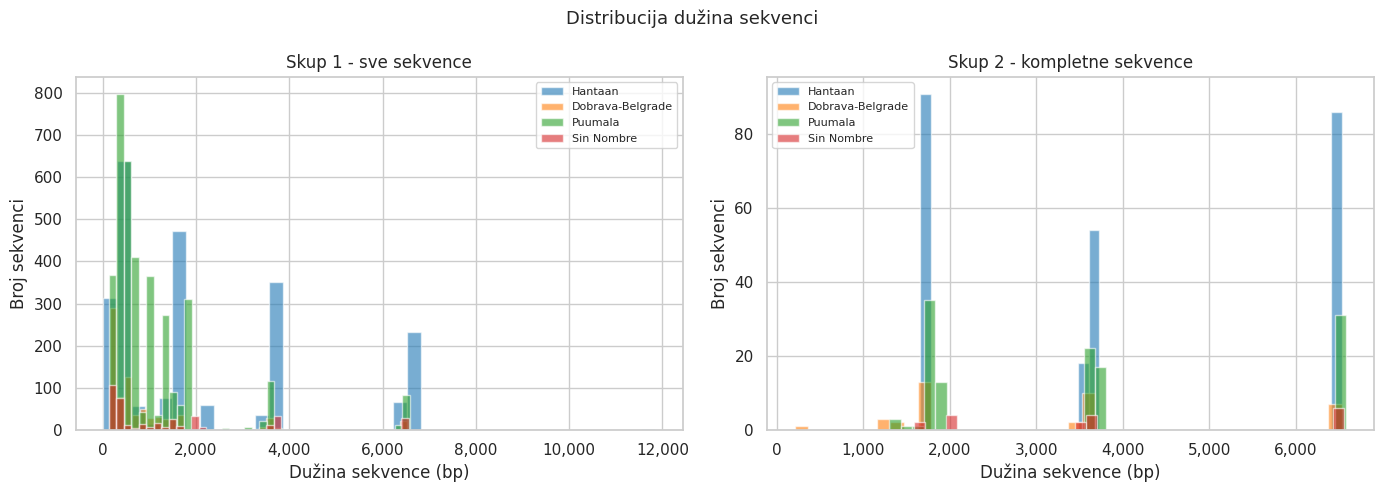


Skup 1 - statistike dužina (bp):
                  min  mean    max
label                             
Dobrava-Belgrade  161   899   6533
Hantaan            17  2054  11845
Puumala           134  1037   6588
Sin Nombre        130  1524   6562

Skup 2 - statistike dužina (bp):
                   min  mean   max
label                             
Dobrava-Belgrade   204  3085  6532
Hantaan           1660  3914  6533
Puumala           1302  3581  6588
Sin Nombre        1589  4035  6562


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df, title) in zip(axes, [(df_all, 'Skup 1 - sve sekvence'), (df_complete, 'Skup 2 - kompletne sekvence')]):
    for sp, color in zip(VIRUSES, PALETTE):
        grp = df[df['species'] == sp]['length']
        if len(grp) > 0:
            ax.hist(grp, bins=40, alpha=0.6, label=SPECIES_LABELS[sp], color=color)
    ax.set_title(title)
    ax.set_xlabel('Dužina sekvence (bp)')
    ax.set_ylabel('Broj sekvenci')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Distribucija dužina sekvenci', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_lengths.png'), dpi=150)
plt.show()

print("\nSkup 1 - statistike dužina (bp):")
print(df_all.groupby('label')['length'].describe()[['min','mean','max']].round(0).astype(int))
print("\nSkup 2 - statistike dužina (bp):")
print(df_complete.groupby('label')['length'].describe()[['min','mean','max']].round(0).astype(int))

**Zapažanja:**
- Distribucija je **multimodalna** - potvrđuje da su u bazi zastupljeni sva tri genomska segmenta (S, M, L)
- U skupu kompletnih sekvenci (`complete`) distribucija je uža i pravilnija, sa jasno razdvojenim vrhovima. Sekvence su celi segmenti standardnih dužina
- U skupu svih sekvenci (`all`) postoje i kratki fragmenti koji predstavljaju parcijalne sekvence (npr. samo deo S segmenta), pa se javljaju i vrednosti ispod 1.000 bp
- Različite vrste virusa imaju segmente sličnih dužina, histogrami se po boji delimično preklapaju, pa dužina sekvence sama po sebi nije dovoljna za razlikovanje vrsta

### 4.3 GC sadržaj

**GC sadržaj** (*GC content*) označava procenat baza guanin (G) i citozin (C) u nukleotidnoj sekvenci. Za razliku od A-T parova koji grade dve vodonične veze, G-C parovi grade **tri vodonične veze**, što ih čini termički stabilnijima.

Kod virusa, GC sadržaj nije slučajan, on odražava **evolucioni pritisak** koji virus trpi u specifičnom domaćinu i geografskom okruženju. Hantavirusi u celini spadaju u AT-bogate viruse (GC sadržaj ≈38-46%), što je karakteristično za RNA viruse negativnog polariteta (*negative-sense RNA viruses*) koji repliciraju u citoplazmi ćelija glodara. Unutar grupe hantavirusa, Dobrava-Belgrade i Hantaan (oba poreklom iz Azije i Balkana) imaju nešto viši GC sadržaj od Sin Nombre virusa (Novi svet, Severna Amerika) i Puumala virusa (Stari svet, Severna Evropa), što može odražavati razlike u domaćinima i geografskom poreklu.

Treba napomenuti i da tri genomska segmenta (S, M, L) nemaju isti GC sadržaj, što je direktna posledica toga šta svaki od njih kodira. Segment L nosi uputstvo za RNA polimerazu, enzim koji mora da funkcioniše veoma precizno, pa su delovi njegove sekvence ostali gotovo nepromenjeni kroz evoluciju. Prirodna selekcija je tokom vremena eliminisala svaku promenu koja bi narušila funkciju tog enzima, što ograničava koje baze mogu stajati na tim pozicijama i čini GC profil L segmenta drugačijim od S i M segmenta. U skupu svih sekvenci (`all`), gde su pomešani fragmenti iz svih segmenata, ova razlika doprinosi **širem rasponu GC vrednosti** na box plotu. U skupu kompletnih sekvenci (`complete`) efekat je manji jer su zastupljeni celi segmenti standardnih dužina.

**Box plot** za svaku vrstu prikazuje:
- **Medijana** - srednja vrednost raspodele GC sadržaja
- **IQR** (*interquartile range*) - box obuhvata srednju polovinu podataka, od 25. do 75. percentila
- **Whiskers** - linije koje se protežu do najdalje vrednosti unutar 1.5 × IQR od ivice box-a
- **Outliers** - izolovane tačke van whiskers-a, sekvence sa neuobičajeno visokim ili niskim GC sadržajem, najčešće kratki fragmenti ili sekvence iz specifičnih genomskih regiona

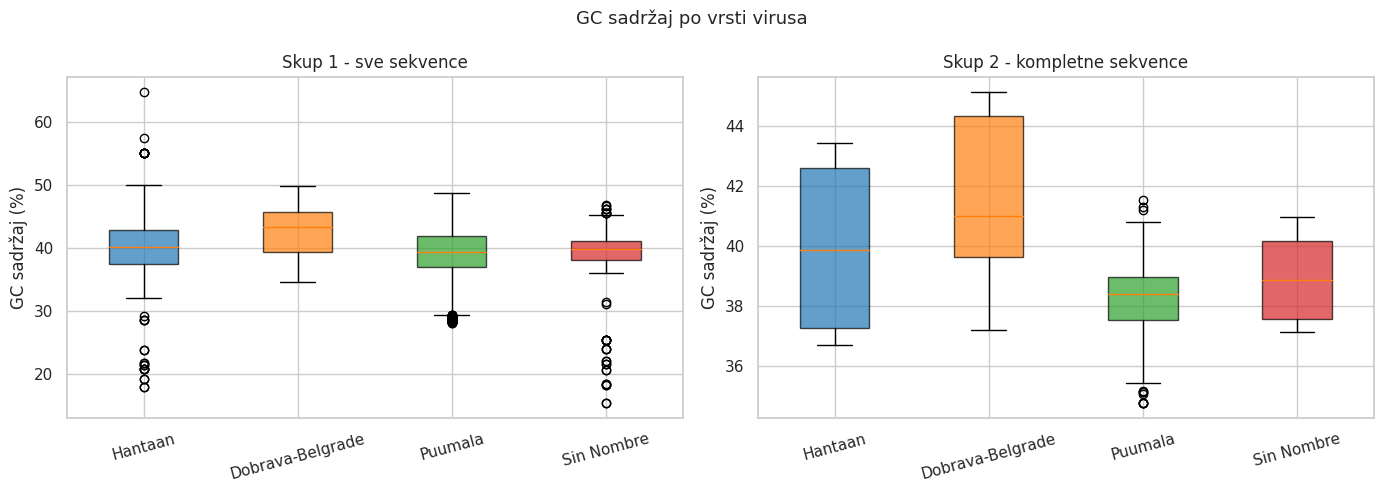


Skup 1 - GC sadržaj (%):
                    min   mean    max
label                                
Dobrava-Belgrade  34.52  42.38  49.85
Hantaan           17.92  40.34  64.71
Puumala           28.02  38.73  48.76
Sin Nombre        15.36  39.15  46.88

Skup 2 - GC sadržaj (%):
                    min   mean    max
label                                
Dobrava-Belgrade  37.21  41.63  45.12
Hantaan           36.71  39.95  43.42
Puumala           34.79  38.06  41.55
Sin Nombre        37.15  39.00  40.97


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df, title) in zip(axes, [(df_all, 'Skup 1 - sve sekvence'), (df_complete, 'Skup 2 - kompletne sekvence')]):
    data_gc = [df[df['species'] == sp]['gc'].values for sp in VIRUSES]
    bp = ax.boxplot(data_gc, patch_artist=True, labels=[SPECIES_LABELS[s] for s in VIRUSES])
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(title)
    ax.set_ylabel('GC sadržaj (%)')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('GC sadržaj po vrsti virusa', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_gc.png'), dpi=150)
plt.show()

print("\nSkup 1 - GC sadržaj (%):")
print(df_all.groupby('label')['gc'].describe()[['min','mean','max']].round(2))
print("\nSkup 2 - GC sadržaj (%):")
print(df_complete.groupby('label')['gc'].describe()[['min','mean','max']].round(2))

**Zapažanja:**
- Sve četiri vrste imaju sličan GC sadržaj u opsegu **≈38-46%**, što je karakteristično za hantaviruse
- Postoje blage razlike između vrsta - box-ovi se delimično preklapaju, ali medijane nisu identične
- U skupu svih sekvenci (`all`) raspon je širi zbog toga što različiti genomski segmenti (S, M, L) imaju različite GC vrednosti
- Sam GC sadržaj nije dovoljan za razlikovanje vrsta jer se opsezi previše poklapaju. K-mer frekvencije su bolji izbor upravo zato što pored udela baza uzimaju u obzir i njihov redosled

### 4.4 Zbirna tabela

Objedinjuje sve ključne statistike po vrsti virusa u jednu preglednu formu i čuva ih kao CSV fajl.

Kolone:
- **N** - ukupan broj sekvenci koje su prošle filter
- **length_min / mean / max** - minimalna, prosečna i maksimalna dužina sekvence (bp)
- **GC_mean** - prosečan GC sadržaj (%)

In [9]:
def summary_table(df, name):
    tbl = df.groupby('label').agg(
        N=('id', 'count'),
        length_min=('length', 'min'),
        length_mean=('length', 'mean'),
        length_max=('length', 'max'),
        GC_mean=('gc', 'mean'),
    ).round({'length_mean': 0, 'GC_mean': 2})
    tbl.to_csv(os.path.join(TAB_DIR, f'summary_{name}.csv'))
    return tbl

print("Skup 1 - sve sekvence:")
display(summary_table(df_all, 'all'))

print("\nSkup 2 - kompletne sekvence:")
display(summary_table(df_complete, 'complete'))

Skup 1 - sve sekvence:


,N,length_min,length_mean,length_max,GC_mean
label,,,,,
Dobrava-Belgrade,780,161,899.0,6533,42.38
Hantaan,2323,17,2054.0,11845,40.34
Puumala,3641,134,1037.0,6588,38.73
Sin Nombre,389,130,1524.0,6562,39.15



Skup 2 - kompletne sekvence:


,N,length_min,length_mean,length_max,GC_mean
label,,,,,
Dobrava-Belgrade,38,204,3085.0,6532,41.63
Hantaan,249,1660,3914.0,6533,39.95
Puumala,123,1302,3581.0,6588,38.06
Sin Nombre,18,1589,4035.0,6562,39.00


**Ključni zaključci:**
- Podaci su **neuravnoteženi** - Sin Nombre je najmanji skup, posebno u `complete` skupu (svega 18 sekvenci)
- Sekvence pokrivaju sva tri genomska segmenta (S, M, L), što se vidi u trimodalnoj distribuciji dužina
- GC sadržaj je sličan kod svih vrsta (≈38-46%), pa se klasifikacija ne može zasnovati samo na ovoj osobini
- Skup kompletnih sekvenci (`complete`) je manji ali "čistiji", sekvence su standardnih dužina bez kratkih fragmenata, što ga čini pogodnijim za analizu k-mer frekvencija

---
## 5. Računanje k-mer frekvencija

**K-mer** je svaki deo nukleotidne sekvence dužine **k** koji dobijamo tako što pomeramo prozor veličine *k* za po jednu poziciju kroz sekvencu. Na primer, za sekvencu `ACGTA` i `k = 3`, k-meri su: `ACG`, `CGT` i `GTA`.

Za sekvencu dužine *L*, ukupan broj k-mera iznosi:

$$
L - k + 1
$$

Pošto radimo sa četiri nukleotida (A, C, G, T), broj **mogućih** k-mera je $4^k$:

| k | Naziv | Broj mogućih k-mera |
|---|-------|---------------------|
| 3 | Trinukleotidi | 64 |
| 4 | Tetranukleotidi | 256 |
| 5 | Pentanukleotidi | 1.024 |
| 6 | Heksanukleotidi | 4.096 |


Za svaku sekvencu računamo koliko puta se svaki k-mer pojavljuje, a rezultat delimo sa ukupnim brojem k-mera u toj sekvenci. Time dobijamo **normalizovani vektor frekvencija**, svojevrsni *genomski potpis* (*genomic signature*) sekvence konzistentan unutar vrste i distinktivan između vrsta. Za razliku od GC sadržaja koji gleda samo koliko ima G i C baza, k-mer profil uzima u obzir i redosled baza, pa nosi više informacije o genomu.

### Zašto k-mer pristup?

Ključna prednost je što je ovo **alignment-free** metoda, ne zahteva poravnanje sekvenci (*multiple sequence alignment*, MSA), koje je računski skupo, podložno greškama i problematično za sekvence znatno različitih dužina. Umesto toga, svaka sekvenca se nezavisno opisuje vektorom frekvencija.

Od svake sekvence na ovaj način dobijamo jedan red u tabeli: identifikator, labela vrste, i 64/256/1024/4096 kolona k-mer frekvencija. Takav dataset direktno možemo proslediti algoritmima mašinskog učenja.

In [10]:
def get_all_kmers(k):
    return [''.join(p) for p in product('ACGT', repeat=k)]

_BASE_MAP = np.zeros(256, dtype=np.int64)
for _b, _v in zip(b'ACGT', [0, 1, 2, 3]):
    _BASE_MAP[_b] = _v

def kmer_frequencies(sequence, k):
    arr = _BASE_MAP[np.frombuffer(sequence.encode('ascii'), dtype=np.uint8)]
    n = len(arr) - k + 1
    if n <= 0:
        return np.zeros(4**k, dtype=np.float32)
    powers = (4 ** np.arange(k - 1, -1, -1)).astype(np.int64)
    s = arr.strides[0]
    windows = np.lib.stride_tricks.as_strided(arr, shape=(n, k), strides=(s, s))
    indices = windows.dot(powers)
    counts = np.bincount(indices, minlength=4**k)
    return (counts / n).astype(np.float32)

def build_kmer_dataset(df, k):
    kmers = get_all_kmers(k)
    print(f"    k={k} ({4**k} feature-a) ... ", end='', flush=True)
    features = np.vstack([kmer_frequencies(seq, k) for seq in df['seq']])
    df_feat = pd.DataFrame(features, columns=kmers)
    df_feat.insert(0, 'species', df['species'].values)
    df_feat.insert(1, 'seq_id',  df['id'].values)
    print("gotovo.")
    return df_feat

datasets = {}

for subset_name, df_src in [('all', df_all), ('complete', df_complete)]:
    print(f"\nSkup: {subset_name}  ({len(df_src)} sekvenci)")
    for k in [3, 4, 5, 6]:
        df_k = build_kmer_dataset(df_src, k)
        datasets[(subset_name, k)] = df_k
        out = os.path.join(PROC_DIR, f'kmer_{subset_name}_k{k}.csv')
        df_k.to_csv(out, index=False)

print("\nSvi k-mer dataseti izračunati.")


Skup: all  (7133 sekvenci)
    k=3 (64 feature-a) ... gotovo.
    k=4 (256 feature-a) ... gotovo.
    k=5 (1024 feature-a) ... gotovo.
    k=6 (4096 feature-a) ... gotovo.

Skup: complete  (428 sekvenci)
    k=3 (64 feature-a) ... gotovo.
    k=4 (256 feature-a) ... gotovo.
    k=5 (1024 feature-a) ... gotovo.
    k=6 (4096 feature-a) ... gotovo.

Svi k-mer dataseti izračunati.


**Rezultat:**

Izračunato je ukupno **8 dataseta**, za svaku kombinaciju skupa podataka (`all`, `complete`) i vrednosti k (3, 4, 5, 6). Svaki dataset je sačuvan kao CSV fajl u `data/processed/`.

| Skup | k | Broj sekvenci | Broj feature-a |
|------|---|---------------|----------------|
| all | 3 | 7.133 | 64 |
| all | 4 | 7.133 | 256 |
| all | 5 | 7.133 | 1.024 |
| all | 6 | 7.133 | 4.096 |
| complete | 3 | 428 | 64 |
| complete | 4 | 428 | 256 |
| complete | 5 | 428 | 1.024 |
| complete | 6 | 428 | 4.096 |

Svaki red u datasetu odgovara jednoj sekvenci i sadrži normalizovane frekvencije svih k-mera. Sa porastom k raste i broj feature-a što može doneti više informacije, ali i povećati računsku kompleksnost i rizik od *preprilagođavanja*. Iz tog razloga u nastavku testiramo sve četiri vrednosti k i poredimo rezultate.

---
## 6. Redukcija dimenzionalnosti - PCA

Nakon računanja k-mer frekvencija, svaka sekvenca je opisana vektorom od **64** do **4096 feature-a** (zavisno od k). Direktna vizualizacija u ovoliko dimenzija nije moguća, pa koristimo **PCA** (*Principal Component Analysis* - analiza glavnih komponenti) da bismo stekli uvid u strukturu podataka pre same klasifikacije.

PCA pronalazi nove ose u prostoru podataka, **glavne komponente** (*principal components - PC*), takve da:
- ***PC1*** objašnjava najveći mogući udeo ukupne varijanse u podacima
- ***PC2*** objašnjava drugi najveći udeo varijanse, pri čemu je ortogonalna (nezavisna) na *PC1*
- Svaka naredna komponenta nastavlja istim principom

Svaka glavna komponenta je linearna kombinacija originalnih k-mer frekvencija. Projektovanjem podataka na prve dve komponente dobijamo 2D prikaz koji čuva što je moguće više informacije iz originalnog prostora.

Pre primene PCA metode, podaci se **standardizuju** korišćenjem *StandardScaler* algoritma, čime se obezbeđuje da svaka karakteristika ima *srednju vrednost 0* i *standardnu devijaciju 1*. Ovo je neophodni korak, jer bez standardizacije k-meri koji se češće pojavljuju dominirali bi PCA-om samo zbog veće apsolutne vrednosti, a ne zbog biološke relevantnosti.

Pratimo dva grafika:

***1. Kriva kumulativne varijanse*** - prikazuje koliko komponenti je potrebno da se pokrije npr. 95% ukupne varijanse. Što manji broj komponenti, to kompaktniji je k-mer prostor i lakše ga je koristiti u klasifikatorima.

***2. Scatter plot (PC1 vs PC2)*** - ukoliko se tačke različitih vrsta jasno grupišu i razdvajaju već u 2D projekciji, to predstavlja dobar pokazatelj da k-mer frekvencije sadrže dovoljno informacija za uspešnu klasifikaciju. Ako se klase prepliću, klasifikatori će imati težak zadatak.

all, k=4: 95% varijanse pokriveno sa 132 komponenti
complete, k=4: 95% varijanse pokriveno sa 65 komponenti


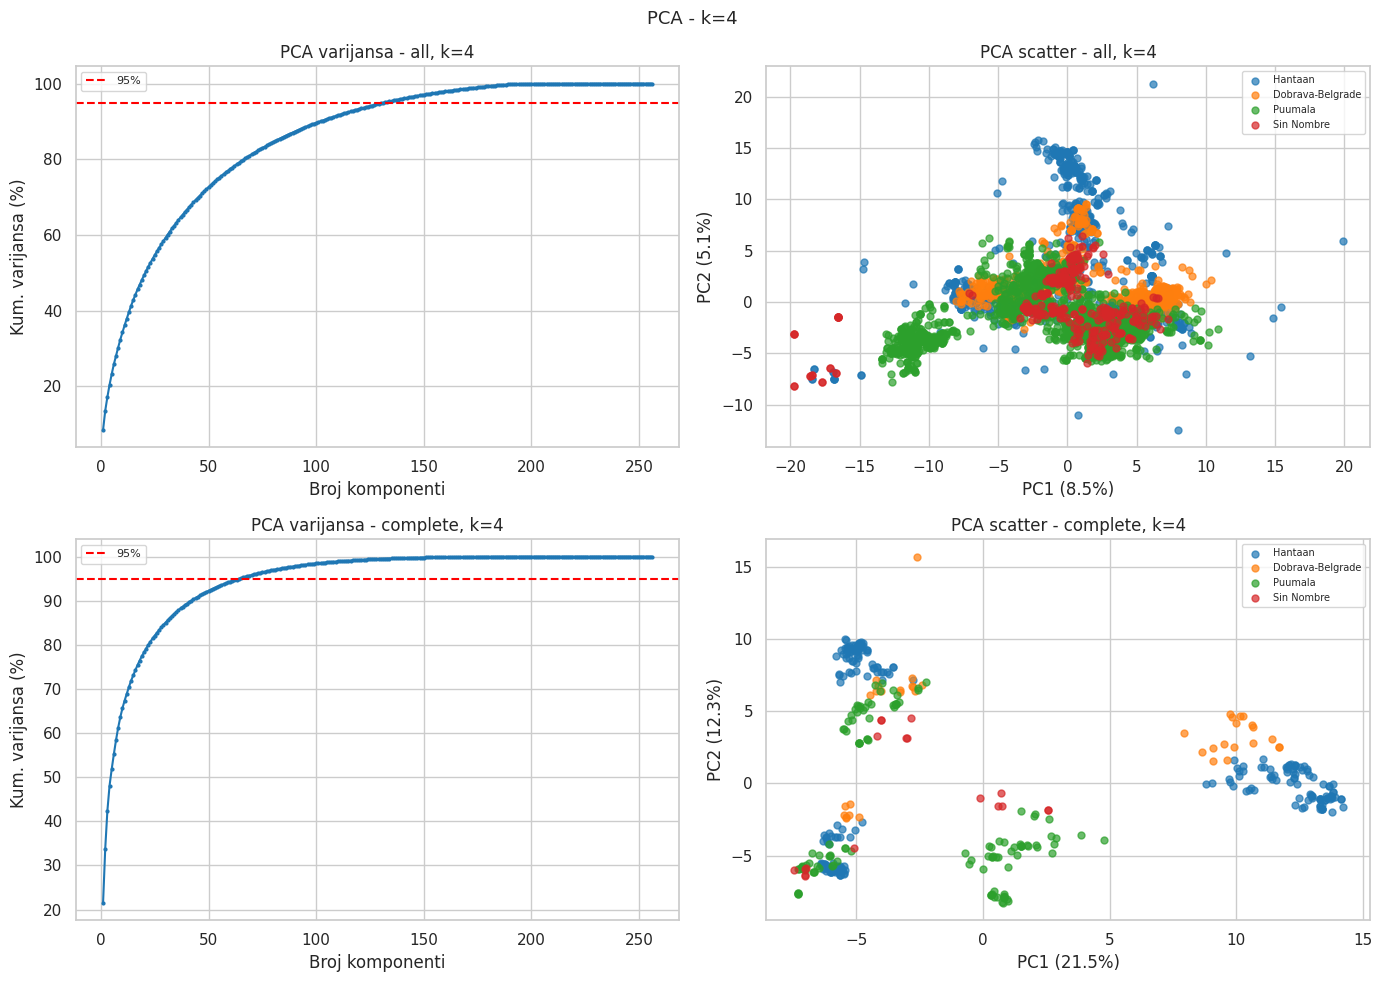

In [11]:
def plot_pca(subset_name, k, ax_var, ax_scatter):
    df_k = datasets[(subset_name, k)]
    feat_cols = [c for c in df_k.columns if c not in ['species', 'seq_id']]
    X = df_k[feat_cols].values
    y = df_k['species'].values

    X_sc = StandardScaler().fit_transform(X)
    n_comp_full = min(X_sc.shape[0] - 1, X_sc.shape[1])
    pca = PCA(n_components=n_comp_full, random_state=42)
    X_pca = pca.fit_transform(X_sc)

    cum_var = np.cumsum(pca.explained_variance_ratio_) * 100
    ax_var.plot(range(1, n_comp_full + 1), cum_var, marker='o', markersize=2)
    ax_var.axhline(95, color='red', linestyle='--', label='95%')
    ax_var.set_xlabel('Broj komponenti')
    ax_var.set_ylabel('Kum. varijansa (%)')
    ax_var.set_title(f'PCA varijansa - {subset_name}, k={k}')
    ax_var.legend(fontsize=8)

    for sp, color in zip(VIRUSES, PALETTE):
        mask = y == sp
        ax_scatter.scatter(X_pca[mask, 0], X_pca[mask, 1], label=SPECIES_LABELS[sp], alpha=0.7, s=25, color=color)
    ax_scatter.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax_scatter.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax_scatter.set_title(f'PCA scatter - {subset_name}, k={k}')
    ax_scatter.legend(fontsize=7)

    return int(np.argmax(cum_var >= 95)) + 1

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, subset in enumerate(['all', 'complete']):
    n95 = plot_pca(subset, 4, axes[row][0], axes[row][1])
    print(f"{subset}, k=4: 95% varijanse pokriveno sa {n95} komponenti")

plt.suptitle('PCA - k=4', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'pca_k4.png'), dpi=150)
plt.show()

**Analiza rezultata (k=4):**

***Kumulativna varijansa:***
- Za pokrivanje 95% varijanse potrebno je **132 komponente** za skup `all` i **65 komponenti** za skup `complete` (od ukupno 256 mogućih za k=4). PC1 objašnjava svega ≈8.5% varijanse u skupu `all`, odnosno ≈21.5% u skupu `complete`, što znači da k-mer prostor nije kompaktan (informacija je raspoređena na mnogo dimenzija)
- Ovakav rezultat je tipičan kada varijansa u podacima nije dominantno uzrokovana razlikama između klasa, već unutarklasnom raznolikošću (različiti genomski segmenti S, M, L unutar iste vrste imaju veoma različite k-mer profile)


***Scatter plot (PC1 vs PC2):***
- U skupu `complete` vrste se jasno razdvajaju u 2D projekciji, klase formiraju kompaktne, odvojene grupe. Ovo je pokazatelj da k-mer profili kompletnih sekvenci nose dovoljno informacija za klasifikaciju
- U skupu `all` razdvajanje je slabije zbog prisustva kratkih fragmenata koji ne sadrže dovoljno karakterističnih k-mer obrazaca cele sekvence, što dovodi do većeg preklapanja između klastera
- Tri virusa Starog sveta (Hantaan, Dobrava-Belgrade, Puumala) i jedini virus Novog sveta (Sin Nombre) grupišu se na različitim stranama PC1 ose, što pokazuje evolutivnu udaljenost između ove dve grupe

PCA potvrđuje da k-mer frekvencije nose biološki smislen signal za razlikovanje vrsta. Skup kompletnih sekvenci daje čistiju separaciju i bolji polazni materijal za klasifikaciju.

---
## 7. Klasifikacija

Cilj klasifikacije je da se na osnovu k-mer frekvencijskog profila sekvence predvidi kojoj vrsti hantavirusa ona pripada. Svaka sekvenca je predstavljena vektorom frekvencija (64 do 4096 vrednosti zavisno od k), a algoritam uči da prepozna karakteristične obrasce koji razlikuju četiri vrste.

### Pipeline

Svaki klasifikator se pokreće unutar **sklearn Pipeline-a** koji se sastoji od tri koraka koji se uvek izvršavaju zajedno:

1. **StandardScaler** - standardizuje feature (mean=0, std=1). Neophodno jer k-meri imaju različite apsolutne frekvencije i bez ovog koraka dominirali bi česti k-meri
2. **PCA** (n_components=50) - redukuje dimenzionalnost sa 64-4096 na 50 komponenti. Ubrzava treniranje, smanjuje šum i uklanja korelisane feature
3. **Classifier** - sam algoritam za klasifikaciju

### Strategija evaluacije

- **Train/test split 80/20** sa stratifikacijom čuva proporciju klasa u oba skupa
- **Stratifikovana 5-fold unakrsna validacija** na trening skupu kao pouzdanija procena generalizacije od jedne podele
- Metrika: **accuracy** (tačnost) - procenat ispravno klasifikovanih sekvenci

Analiza se pokreće za oba skupa podataka (`all`, `complete`) i sve četiri vrednosti k (3, 4, 5, 6) - ukupno 8 kombinacija × 5 algoritama = **40 modela**.

In [12]:
CLASSIFIERS = {
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'SVM (RBF)': SVC(kernel='rbf', C=10, gamma='scale', random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
}

def run_classification(subset_name, k, n_pca=50, cv_n_jobs=-1):
    df_k = datasets[(subset_name, k)]
    feat_cols = [c for c in df_k.columns if c not in ['species', 'seq_id']]
    X = df_k[feat_cols].values
    y = LabelEncoder().fit_transform(df_k['species'].values)
    le = LabelEncoder().fit(df_k['species'].values)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    results = []

    for name, clf in CLASSIFIERS.items():
        n_comp = min(n_pca, X_train.shape[0]-1, X_train.shape[1])
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('pca', PCA(n_components=n_comp, random_state=42)),
            ('clf', clf),
        ])
        cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=cv_n_jobs)
        pipe.fit(X_train, y_train)
        test_acc = accuracy_score(y_test, pipe.predict(X_test))

        results.append({
            'Algoritam': name,
            'CV mean': round(cv_scores.mean(), 4),
            'CV std': round(cv_scores.std(), 4),
            'Test accuracy': round(test_acc, 4),
        })
        tag = f'{name.replace(" ","_")}_{subset_name}_k{k}'
        joblib.dump({'pipe': pipe, 'le': le, 'X_test': X_test, 'y_test': y_test}, os.path.join(MOD_DIR, f'{tag}.pkl'))

    df_res = pd.DataFrame(results).sort_values('Test accuracy', ascending=False)
    df_res.to_csv(os.path.join(TAB_DIR, f'clf_{subset_name}_k{k}.csv'), index=False)
    return df_res

print("Funkcije definisane.")

Funkcije definisane.


### Izbor klasifikatora

Izabrano je pet algoritama koji pokrivaju različite klase pristupa u mašinskom učenju:

| Algoritam | Zašto |
|-|-|
| **Random Forest** | Robustan na overfitting, stabilan na nebalansiranim skupovima, direktno daje feature importance za interpretaciju k-mera |
| **SVM (RBF kernel)** | Odličan u visokodimenzionalnim prostorima, RBF kernel hvata nelinearne granice između klasa, tipično jedan od najjačih klasifikatora za genomske podatke |
| **KNN** | Jednostavan ali efektivan baseline, klasifikuje na osnovu sličnosti k-mer profila sa najbližim susedima u prostoru |
| **Gradient Boosting** | Sekvencijalno gradi stabla korigovanjem grešaka prethodnika, visoka tačnost, ali osetljiv na overfitting |
| **Logistic Regression** | Najjednostavniji model, služi kao donji prag (baseline), ali ako i on postiže visoku tačnost, znači da su klase linearno separabilne u PCA prostoru |

Kombinacija ovih pet pokriva spektar od jednostavnih linearnih modela do kompleksnih nelinearnih metoda, što omogućava smisleno poređenje.

In [13]:
import gc
import time

t0 = time.time()
all_results = {}

for subset in ['all', 'complete']:
    for k in [3, 4, 5, 6]:
        cv_jobs = 1 if k == 6 and subset == 'all' else -1
        print(f"\n=========  Skup: {subset}, k={k} (cv_n_jobs={cv_jobs})  =========")
        df_res = run_classification(subset, k, cv_n_jobs=cv_jobs)
        all_results[(subset, k)] = df_res
        print(df_res.to_string(index=False))
        # Oslobodi memoriju za all+k>=5 odmah nakon klasifikacije
        # ovi dataseti su veliki i više nisu potrebni u nastavku
        if subset == 'all' and k >= 5:
            del datasets[(subset, k)]
            gc.collect()

elapsed = time.time() - t0
print(f"\nElapsed time: {elapsed:.1f}s ≈ {elapsed/60:.1f}min")


=========  Skup: all, k=3 (cv_n_jobs=-1)  =========
          Algoritam  CV mean  CV std  Test accuracy
          SVM (RBF)   0.9923  0.0030         0.9930
                KNN   0.9804  0.0021         0.9874
      Random Forest   0.9765  0.0033         0.9818
  Gradient Boosting   0.9725  0.0033         0.9797
Logistic Regression   0.9069  0.0067         0.9075

=========  Skup: all, k=4 (cv_n_jobs=-1)  =========
          Algoritam  CV mean  CV std  Test accuracy
          SVM (RBF)   0.9916  0.0023         0.9916
      Random Forest   0.9834  0.0049         0.9874
                KNN   0.9858  0.0018         0.9846
  Gradient Boosting   0.9797  0.0021         0.9839
Logistic Regression   0.9550  0.0043         0.9537

=========  Skup: all, k=5 (cv_n_jobs=-1)  =========
          Algoritam  CV mean  CV std  Test accuracy
          SVM (RBF)   0.9890  0.0017         0.9916
      Random Forest   0.9855  0.0020         0.9909
  Gradient Boosting   0.9842  0.0037         0.9909
         

### 7.1 Poređenje rezultata - za svako k i oba skupa

Grafik prikazuje kako se test accuracy menja sa porastom k za svaki algoritam, posebno za `all` i `complete` skup. Ovo omogućava direktno poređenje stabilnosti algoritama i optimalnog izbora k.

    Skup  k      Najbolji model  CV mean  Test accuracy
     all  3           SVM (RBF)   0.9923         0.9930
     all  4           SVM (RBF)   0.9916         0.9916
     all  5           SVM (RBF)   0.9890         0.9916
     all  6       Random Forest   0.9881         0.9909
complete  3 Logistic Regression   0.9912         0.9767
complete  4                 KNN   0.9883         1.0000
complete  5           SVM (RBF)   0.9971         1.0000
complete  6       Random Forest   0.9796         1.0000


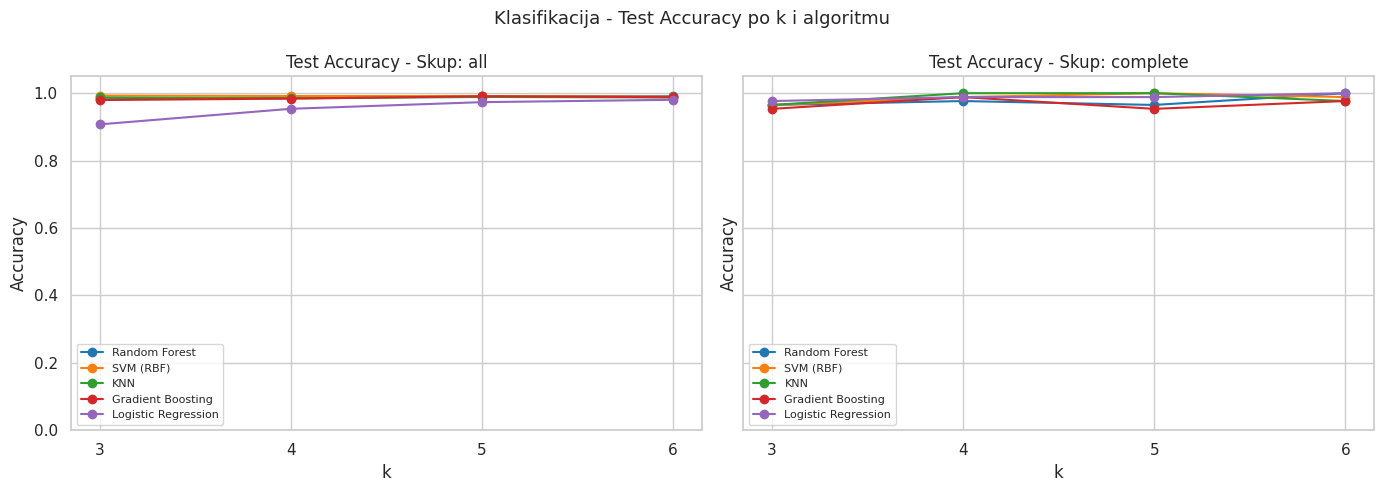

In [14]:
rows = []
for (subset, k), df_res in all_results.items():
    best = df_res.iloc[0]
    rows.append({
        'Skup': subset,
        'k': k,
        'Najbolji model': best['Algoritam'],
        'CV mean': best['CV mean'],
        'Test accuracy': best['Test accuracy'],
    })

df_compare = pd.DataFrame(rows)
df_compare.to_csv(os.path.join(TAB_DIR, 'clf_comparison.csv'), index=False)
print(df_compare.to_string(index=False))

# Grafik
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, subset in zip(axes, ['all', 'complete']):
    sub = df_compare[df_compare['Skup'] == subset]
    for i, (_, row) in enumerate(sub.iterrows()):
        clf_results = all_results[(subset, row['k'])]
        ax.bar(
            [f"k={row['k']}\n{clf['Algoritam'][:6]}" for _, clf in clf_results.iterrows()],
            clf_results['Test accuracy'],
            alpha=0.7
        )
    # Jednostavniji grafik - samo best po k
    ax.cla()
    for clf_name in CLASSIFIERS:
        vals = []
        for k in [3,4,5,6]:
            row = all_results[(subset, k)]
            match = row[row['Algoritam'] == clf_name]
            vals.append(match['Test accuracy'].values[0] if len(match) else 0)
        ax.plot([3,4,5,6], vals, marker='o', label=clf_name)
    ax.set_title(f'Test Accuracy - Skup: {subset}')
    ax.set_xlabel('k')
    ax.set_ylabel('Accuracy')
    ax.set_xticks([3,4,5,6])
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)

plt.suptitle('Klasifikacija - Test Accuracy po k i algoritmu', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'clf_accuracy_comparison.png'), dpi=150)
plt.show()

**Zapažanja sa grafika:**
- Na `all` skupu jedina kriva koja vidljivo raste sa k je **Logistic Regression**, sve ostale su visoke i ravne već od k=3, što znači da trinukleotidi nose dovoljno signal za nelinearne modele
- Na `complete` skupu krive su znatno promenljivije jer je test skup mali (86 sekvenci)  i jedna pogrešna predikcija znači pad od ≈1.2%, pa male razlike između k vrednosti ne treba preterano interpretirati
- Na `complete` skupu 100% tačnost se postiže na različitim k vrednostima za različite algoritme: KNN već na k=4, SVM na k=5, Random Forest i Logistic Regression tek na k=6

### 7.2 Matrice konfuzije - svi klasifikatori

**Matrica konfuzije** prikazuje za svaki par (stvarna klasa, predikcija) koliko sekvenci je ispravno ili pogrešno klasifikovano. Glavna dijagonala (gore-levo do dole-desno) predstavlja tačne predikcije, a vrednosti van nje su greške.

- **Redovi** = stvarna klasa sekvence
- **Kolone** = klasa koju je model predvideo
- **Idealan model** ima sve vrednosti na glavnoj dijagonali i nule svuda drugde

Prikazujemo matricu za `complete` skup i k=4 (jedna od kombinacija sa najboljim rezultatima).

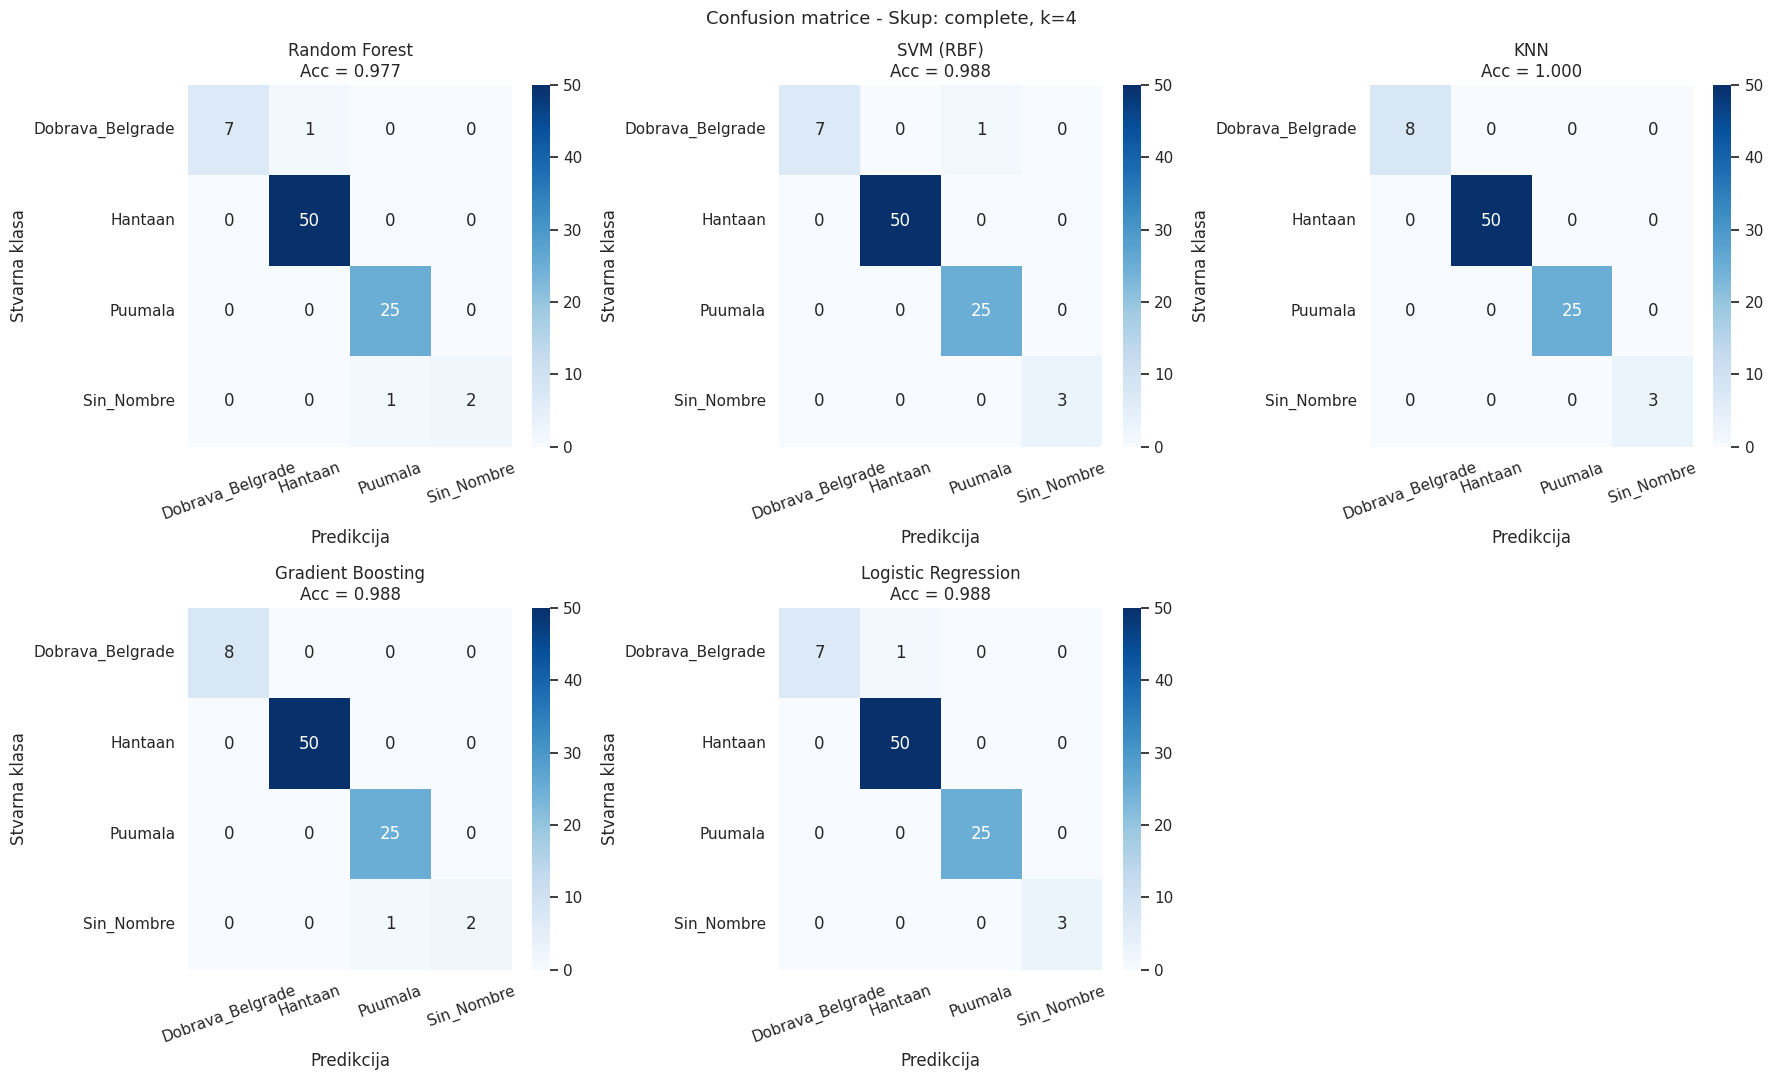

In [15]:
# Promena parametara za prikaz drugih kombinacija
BEST_SUBSET = 'complete'
BEST_K = 4

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, clf_name in enumerate(CLASSIFIERS):
    tag = f'{clf_name.replace(" ","_")}_{BEST_SUBSET}_k{BEST_K}'
    saved = joblib.load(os.path.join(MOD_DIR, f'{tag}.pkl'))
    pipe, le, X_test, y_test = saved['pipe'], saved['le'], saved['X_test'], saved['y_test']
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
    acc = accuracy_score(y_test, y_pred)
    axes[i].set_title(f'{clf_name}\nAcc = {acc:.3f}')
    axes[i].set_xlabel('Predikcija')
    axes[i].set_ylabel('Stvarna klasa')
    axes[i].tick_params(axis='x', rotation=20)

axes[-1].axis('off')
plt.suptitle(f'Confusion matrice - Skup: {BEST_SUBSET}, k={BEST_K}', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f'confusion_{BEST_SUBSET}_k{BEST_K}.png'), dpi=150)
plt.show()

**Zapažanja:**
- KNN postiže savršenu matricu - sve sekvence su ispravno klasifikovane, nema nijedne greške
- Eventualne greške kod ostalih algoritama najčešće se javljaju između Hantaan i Dobrava-Belgrade (oba virusa Starog sveta sa sličnijim k-mer profilima) ili na Sin Nombre klasi koja ima svega 3 sekvence u test skupu
- Čisto plava dijagonala bez vrednosti van nje vizuelno potvrđuje visoku tačnost modela

### 7.3 Classification report - najbolji model

**Classification report** daje detaljan pregled performansi po svakoj klasi posebno:

- **Precision** - od svih sekvenci koje je model svrstao u klasu X, koliki procenat zaista pripada klasi X
- **Recall** - od svih sekvenci koje stvarno pripadaju klasi X, koliki procenat je model ispravno prepoznao
- **F1-score** - harmonijska sredina precision i recall, koristan kad su klase neuravnotežene
- **Support** - broj sekvenci te klase u test skupu

In [16]:
best_row = all_results[(BEST_SUBSET, BEST_K)].iloc[0]
best_clf_name = best_row['Algoritam']

tag = f'{best_clf_name.replace(" ","_")}_{BEST_SUBSET}_k{BEST_K}'
saved = joblib.load(os.path.join(MOD_DIR, f'{tag}.pkl'))
pipe, le, X_test, y_test = saved['pipe'], saved['le'], saved['X_test'], saved['y_test']
y_pred = pipe.predict(X_test)

print(f"Najbolji model: {best_clf_name} (Skup={BEST_SUBSET}, k={BEST_K})")
print(f"Test Accuracy: {best_row['Test accuracy']}\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Najbolji model: KNN (Skup=complete, k=4)
Test Accuracy: 1.0

                  precision    recall  f1-score   support

Dobrava_Belgrade       1.00      1.00      1.00         8
         Hantaan       1.00      1.00      1.00        50
         Puumala       1.00      1.00      1.00        25
      Sin_Nombre       1.00      1.00      1.00         3

        accuracy                           1.00        86
       macro avg       1.00      1.00      1.00        86
    weighted avg       1.00      1.00      1.00        86



**Zapažanja:**
- Kod modela sa 100% tačnošću sve metrike (precision, recall, F1) iznose 1.00 za svaku klasu
- Sin Nombre klasa ima najmanji support (3 sekvence u test skupu), visoke metrike na njoj treba uzeti sa rezervom jer i jedna greška dramatično menja broj

**Napomena: interpretacija tačnosti 1.0**

Tačnost 1.0 (100%) na test skupu ne mora biti znak preprilagođavanja (*overfitting*). Overfitting bi izgledao drugačije: visoka tačnost na trening skupu i znatno niža na test skupu. Ovde to nije slučaj, jer i CV skorovi i test accuracy su visoki i konzistentni, što znači da model dobro generalizuje.

Četiri analizirana hantavirusa su evolutivno veoma udaljena. Hantaan i Sin Nombre su se razdvojili pre desetina miliona godina, koevoluirajući sa različitim domaćinima na različitim kontinentima. Razlike u njihovim genomskim potpisima su dovoljno velike da su klase jasno razdvojene već u 2D PCA projekciji. Kada su klase toliko dobro razdvojene u feature prostoru, 100% tačnost na test skupu je sasvim moguća.

Pravi problem nije overfitting, nego veličina test skupa. Skup `complete` sadrži ukupno **428 sekvenci** (249 Hantaan + 38 Dobrava-Belgrade + 123 Puumala + 18 Sin Nombre), od kojih 80/20 podela izdvaja **86 sekvenci za testiranje** (342 ostaje za treniranje). Sa svega 86 sekvenci u testu, od kojih su samo 3 Sin Nombre, jedan pogrešan odgovor bio bi ≈33% greška na toj klasi, pa i visoka tačnost treba da se uzme sa rezervom. Pored toga, sekvence iz iste virusne izolacije raspoređene i u trening i test skup mogu biti gotovo identične, što daje lažan utisak o generalizaciji na stvarno nove sekvence.

---
### Zaključak klasifikacije

Kompletno poređenje svih algoritama, skupova i vrednosti k prikazano je u sekciji 7.1. Ovde su izdvojeni ključni nalazi:

- **`complete` skup daje bolje rezultate** uprkos tome što ima 17 puta manje sekvenci od `all`, kompletni genomski segmenti nose konzistentniji k-mer potpis od fragmentiranih sekvenci
- **SVM (RBF) je najstabilniji algoritam** kroz sve kombinacije skupova i vrednosti k i posebno dominira na `all` skupu
- **k=3 je iznenađujuće moćan** na velikom skupu (99.3% tačnosti), trinukleotidna kompozicija sama po sebi dovoljna je za razlikovanje vrsta kada je uzoraka dovoljno
- **k=4 i k=5 su optimalni za `complete`** skup, dovoljno konteksta za savršenu separaciju, bez računske cene k=6
- **Logistic Regression** (linearni model) postiže visoku tačnost na `complete` skupu, što potvrđuje da su kompletni genomski potpisi linearno separabilni u PCA prostoru i da su klase biološki distinktivne

---
## 8. Najznačajniji k-meri

Klasifikatori poput Random Forest-a, pored same predikcije, daju i **feature importance** - ocenu koliko svaki feature (ovde je to svaki k-mer) doprinosi donošenju odluke o klasifikaciji. Ova vrednost se računa na osnovu toga koliko svaki k-mer smanjuje nečistoću (Gini impurity) u čvorovima stabala, usrednjena preko svih stabala u ansamblu.

Analiza najznačajnijih k-mera daje biološki uvid: k-meri sa visokom važnošću su oni čija je frekvencija dosledno različita između vrsta, tj. oni koji nose najveći deo genomskog potpisa koji razlikuje hantaviruse.

Analiza se vrši na skupu `complete` i k=4 iz sledećih razloga:
- **`complete`** - kompletne sekvence daju čistiji i pouzdaniji k-mer profil od `all` skupa koji sadrži kratke fragmente sa nepotpunim genomskim potpisom, što je potvrđeno u sekcijama 6 i 7
- **k=4** - minimalna vrednost k pri kojoj se postiže savršena ili skoro savršena klasifikacija na `complete` skupu (KNN dostiže 100% već na k=4); feature importance na k=4 odražava signal koji je dovoljan za razlikovanje vrsta, bez nepotrebnog povećanja prostora na 1.024 ili 4.096 dimenzija

Top 20 najznačajnijih k-mera (skup=complete, k=4):
kmer  importance
AATG    0.053635
AAAA    0.042853
GACT    0.038620
TAAT    0.029218
AGCA    0.026490
ACTT    0.025181
GTGA    0.025026
AGGC    0.022243
CCTG    0.020663
AAAC    0.019979
TAGC    0.019282
CAGT    0.017582
GATA    0.015146
GCTA    0.014877
CGTG    0.014837
TCTG    0.013957
AGGT    0.013675
GGGG    0.013534
TGAC    0.013327
ACAA    0.013091


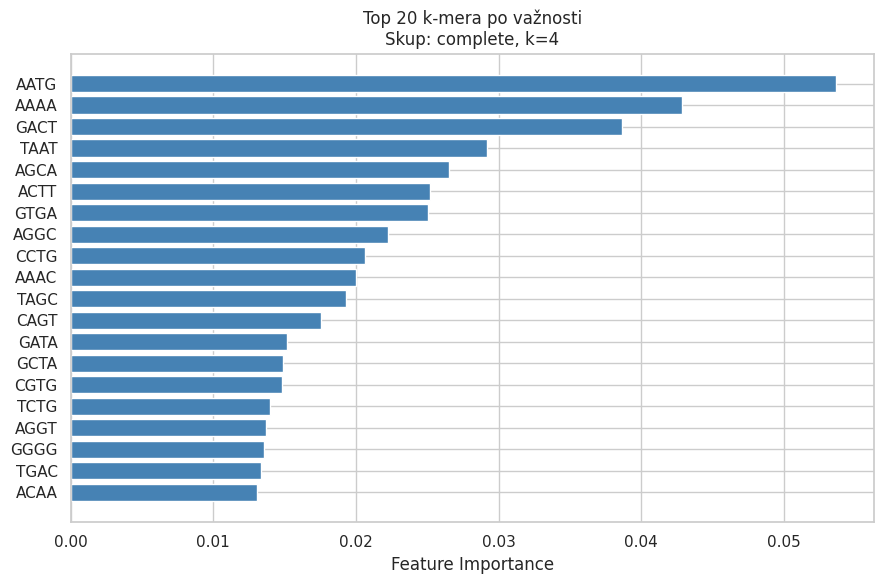

In [17]:
IMP_SUBSET = 'complete'
IMP_K = 4
TOP_N = 20

df_k = datasets[(IMP_SUBSET, IMP_K)]
feat_cols = [c for c in df_k.columns if c not in ['species', 'seq_id']]
X = df_k[feat_cols].values
y = LabelEncoder().fit_transform(df_k['species'].values)

rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1))
])
rf_pipe.fit(X, y)

importances = rf_pipe.named_steps['clf'].feature_importances_
df_imp = pd.DataFrame({'kmer': feat_cols, 'importance': importances}).sort_values('importance', ascending=False)
df_imp.to_csv(os.path.join(TAB_DIR, f'kmer_importance_{IMP_SUBSET}_k{IMP_K}.csv'), index=False)

print(f"Top {TOP_N} najznačajnijih k-mera (skup={IMP_SUBSET}, k={IMP_K}):")
print(df_imp.head(TOP_N).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
top = df_imp.head(TOP_N)
ax.barh(top['kmer'][::-1], top['importance'][::-1], color='steelblue')
ax.set_xlabel('Feature Importance')
ax.set_title(f'Top {TOP_N} k-mera po važnosti\nSkup: {IMP_SUBSET}, k={IMP_K}')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f'feature_importance_{IMP_SUBSET}_k{IMP_K}.png'), dpi=150)
plt.show()

**Analiza rezultata:**

Top 20 k-mera zajedno pokriva ≈45% ukupne važnosti modela, raspoređenih na 256 mogućih tetranukleotida. To znači da preostalih 55% važnosti leži u 236 k-mera koji pojedinačno doprinose malo, ali kolektivno čine značajan deo signala. Nijedan k-mer ne dominira drastično, AATG je prvi sa ≈5.4%, a vrednosti postepeno opadaju. Ovakva raspodela ukazuje da klasifikator ne oslanja svoju odluku na nekoliko ključnih pozicija u genomu, već hvata razlike između vrsta kroz širok skup kratkih sekvencnih obrazaca raspoređenih po celom genomu.

Posmatrajući listu top k-mera, primetno je da su visoko rangirani pretežno oni koji su **AT-bogati** (AATG, AAAA, TAAT i slični). Ovo nije slučajno, kao što je pokazano u sekciji 4.3, hantavirusi se međusobno razlikuju po GC sadržaju, a te razlike direktno utiču na to koliko često se AT-bogati k-meri pojavljuju u sekvencama svake vrste. Model ih stoga prepoznaje kao korisne signale za razlikovanje vrsta, što je u skladu sa biološkom osnovom opisanom u ranijim sekcijama.

---
## 9. Zaključak

Cilj rada bio je da se na osnovu k-mer frekvencijskog profila nukleotidnih sekvenci izgradi model koji može da identifikuje vrstu hantavirusa. Analizirana su četiri virusa (Hantaan, Dobrava-Belgrade, Puumala, Sin Nombre), dva skupa podataka (`all` i `complete`) i četiri vrednosti k (3, 4, 5, 6), ukupno 40 modela.

### Koji skup podataka daje bolje rezultate?

Skup kompletnih sekvenci (`complete`) daje bolje i pouzdanije rezultate uprkos tome što je 17 puta manji od skupa svih sekvenci (428 naspram 7133 sekvenci). Razlog je strukturna konzistentnost: svaka kompletna sekvenca pokriva ceo genomski segment (S, M ili L) u standardnoj dužini, pa k-mer profil odražava stvarni genomski potpis vrste. U skupu svih sekvenci prisutni su kratki fragmenti koji nemaju karakteristični k-mer raspored cele sekvence i unose šum u feature prostor.

### Koja vrednost k daje najbolju klasifikaciju?

Na skupu `complete`, k=4 (tetranukleotidi, 256 feature-a) je minimalna vrednost k koja dozvoljava savršenu ili skoro savršenu klasifikaciju - KNN postiže 100% test accuracy već na k=4, a više algoritama postiže 100% na k=5 i k=6. Povećanje k iznad 5 ne donosi poboljšanje rezultata, ali eksponencijalno povećava broj feature-a i računsku cenu (k=6 zahteva 4096 dimenzija i traje višestruko duže).

Na skupu `all`, k=3 je iznenađujuće efikasno - SVM postiže 99.3% tačnosti već na trinukleotidima. Ovo sugeriše da pri dovoljnom broju sekvenci i kratki nukleotidni obrasci mogu biti dovoljni za razlikovanje vrsta.

### Koji algoritam je najtačniji?

**SVM sa RBF kernelom** je najtačniji i najstabilniji algoritam ukupno, dominira na skupu `all` za sve vrednosti k i postiže 100% na `complete` skupu za k=5. Njegova prednost je sposobnost pronalaženja nelinearnih granica između klasa u visokodimenzionalnim prostorima, što je upravo slučaj kod k-mer feature prostora.

**KNN** postiže odlične rezultate na `complete` skupu (100% za k=4), ali je osetljiviji na male skupove i varira više sa promenom k.

**Logistic Regression** kao najjednostavniji model postiže visoku tačnost na `complete` skupu (100% za k=6), što potvrđuje da su kompletni genomski potpisi linearno separabilni u PCA prostoru (biološka distinktivnost vrsta je dovoljno jaka da je i linearni model može uhvatiti).

### Koji k-meri su najznačajniji za razlikovanje vrsta?

Analiza feature importance (skup `complete`, k=4) pokazuje da nijedan k-mer ne dominira sam. Top 20 k-mera zajedno pokriva ≈45% ukupne važnosti, a klasifikator koristi širi skup signala kolektivno.

Najznačajniji k-meri su pretežno **AT-bogati motivi**: `AATG` (5.4%), `AAAA` (4.3%), `TAAT` (2.9%). Ovo je u skladu sa razlikama u GC sadržaju između vrsta opisanim u sekciji 4.3 - Puumala, sa najnižim prosečnim GC sadržajem u grupi, ima posledično više frekvencije AT-bogatih k-mera, što ga čini lako prepoznatljivim za model.

### Opšti zaključak

K-mer analiza se pokazala kao efikasan pristup za klasifikaciju hantavirusa. Metoda je **alignment-free**, računski pristupačna i daje visoku tačnost bez ikakve prethodne biološke pretpostavke o sekvencama. Rezultati potvrđuju da genomski potpis, karakteristični raspored kratkih nukleotidnih sekvenci, nosi dovoljno informacije da jednoznačno odredi vrstu virusa, što je u skladu sa evolutivnom istorijom ove grupe (virusi koji su dugo koevoluirali sa različitim domaćinima na različitim kontinentima razvili su prepoznatljive genomske potpise).

In [18]:
print("Rezultati sačuvani u:")
print(f"  Tabele:  {TAB_DIR}")
print(f"  Grafici: {FIG_DIR}")
print(f"  Modeli:  {MOD_DIR}")

Rezultati sačuvani u:
  Tabele:  /home/user/Desktop/hantavirus_kmer_analysis/results/tables
  Grafici: /home/user/Desktop/hantavirus_kmer_analysis/results/figures
  Modeli:  /home/user/Desktop/hantavirus_kmer_analysis/models
